# 🎓 AI vs Real: Image Detection with Transfer Learning

**Updated version using pretrained ResNet-50.** This notebook upgrades the
original SimpleCNN approach to use transfer learning, which typically gives
a large accuracy jump (often from ~80% to 92-97%).

### What changed from the original

| Component | Original | Updated |
|---|---|---|
| Model | SimpleCNN trained from scratch | Pretrained ResNet-50, fine-tuned |
| Augmentation | Flip + small rotation | + ColorJitter + RandomResizedCrop |
| Optimizer | Adam, lr=1e-3 | AdamW, lr=1e-4, weight_decay=1e-4 |
| Splits | Train / Test only | Train / Val / Test (proper held-out) |
| Model selection | Final epoch | Best validation accuracy (checkpointed) |
| LR schedule | StepLR (halve every 5) | CosineAnnealingLR (smooth decay) |

### Why pretrained?

Training a CNN from scratch on ~6,000 images means starting from random weights
and hoping the network discovers useful visual features in 15 epochs. ResNet-50
starts already knowing how to detect edges, textures, materials, faces, and
thousands of other patterns because it was pretrained on ImageNet's 1.2 million
images. We only need to teach it the final 'is this real or AI?' decision.

## Step 1: Setup & Import Libraries

In [1]:
# Import libraries
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Disable Pillow's decompression-bomb safety limit.
# Some real photos in the dataset are very large (e.g. 15000x16000).
# We trust the source, so we raise the cap rather than crash mid-training.
Image.MAX_IMAGE_PIXELS = None

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models  # <-- NEW: pretrained models

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device: prefer CUDA, then Apple Silicon MPS, fall back to CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

Device: mps


## Step 2: Load Dataset

Same sampling strategy as before: equal numbers from each class for a balanced
training set. If you want to use *all* the fake images (handling imbalance with
class weights), see the note in Step 7.

In [2]:
# ============================================================
# CONFIG
# ============================================================
SAMPLES_PER_CLASS = 3781   # 'real' folder has 3,781 -> that's the max for balanced
DATASET_PATH = '/Users/tavish/Downloads/dalle_dataset'

# Expected folder structure:
# dataset/
#   |-- real/
#   |-- fake/

def list_image_files(folder):
    """Return full paths of every image file in a folder."""
    if not os.path.exists(folder):
        print(f'  WARNING: folder not found -> {folder}')
        return []
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    return [os.path.join(folder, f) for f in files]

def sample_class(folder, n, label):
    """Randomly pick n image paths from a folder and tag them with label."""
    all_files = list_image_files(folder)
    if len(all_files) == 0:
        return [], []
    n = min(n, len(all_files))
    chosen = random.sample(all_files, n)
    print(f'  {folder}: picked {n} of {len(all_files)} images')
    return chosen, [label] * n

def load_images(dataset_path, n_per_class):
    real_paths, real_labels = sample_class(
        os.path.join(dataset_path, 'real'), n_per_class, 0)   # 0 = Real
    fake_paths, fake_labels = sample_class(
        os.path.join(dataset_path, 'fake'), n_per_class, 1)   # 1 = AI/Fake
    return real_paths + fake_paths, real_labels + fake_labels

print('Sampling images...')
image_paths, labels = load_images(DATASET_PATH, SAMPLES_PER_CLASS)

df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'\nTotal images: {len(df)}')
print('\nClass distribution:')
print(df['label'].value_counts())
print('\n0 = Real | 1 = AI-Generated')

Sampling images...
  /Users/tavish/Downloads/dalle_dataset/real: picked 3780 of 3780 images
  /Users/tavish/Downloads/dalle_dataset/fake: picked 3781 of 17855 images

Total images: 7561

Class distribution:
label
1    3781
0    3780
Name: count, dtype: int64

0 = Real | 1 = AI-Generated


## Step 3: Exploratory Data Analysis (EDA)

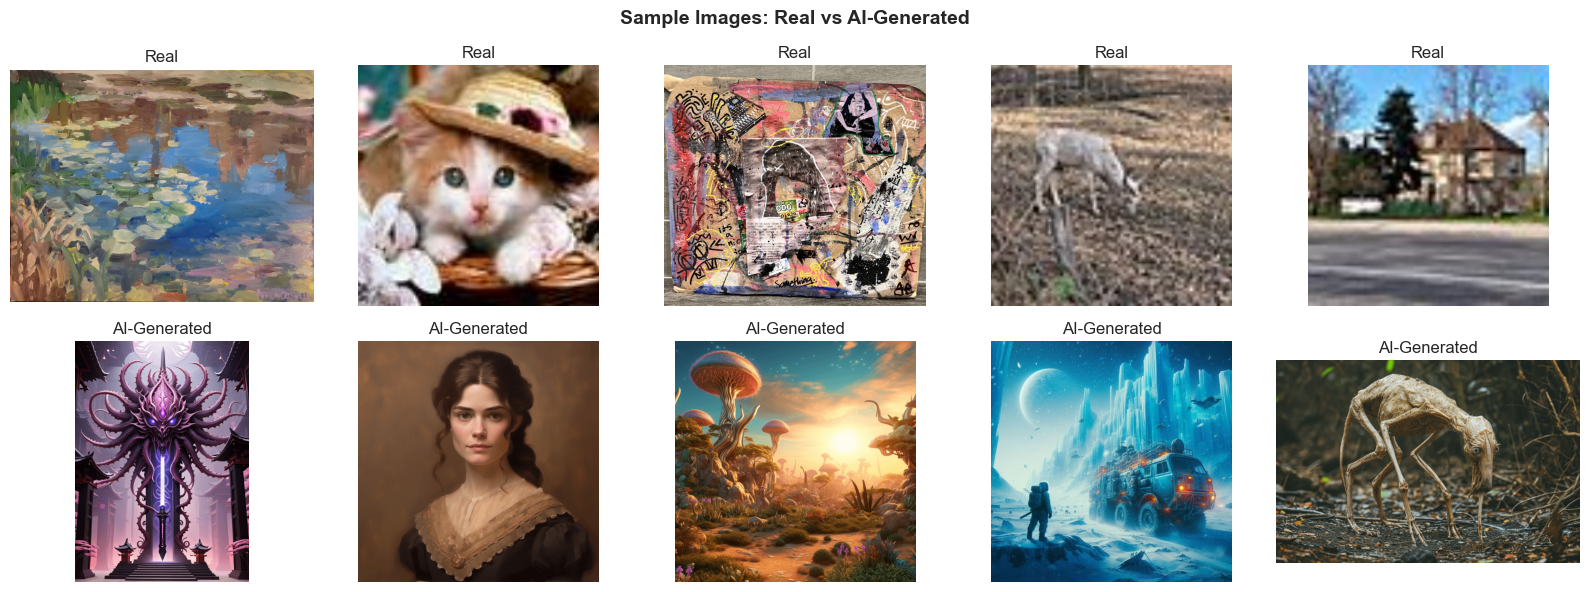

In [3]:
# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Sample Images: Real vs AI-Generated', fontsize=14, fontweight='bold')

real_samples = df[df['label'] == 0].sample(5, random_state=SEED)
for idx, (_, row) in enumerate(real_samples.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    axes[0, idx].imshow(img)
    axes[0, idx].set_title('Real')
    axes[0, idx].axis('off')

fake_samples = df[df['label'] == 1].sample(5, random_state=SEED)
for idx, (_, row) in enumerate(fake_samples.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    axes[1, idx].imshow(img)
    axes[1, idx].set_title('AI-Generated')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

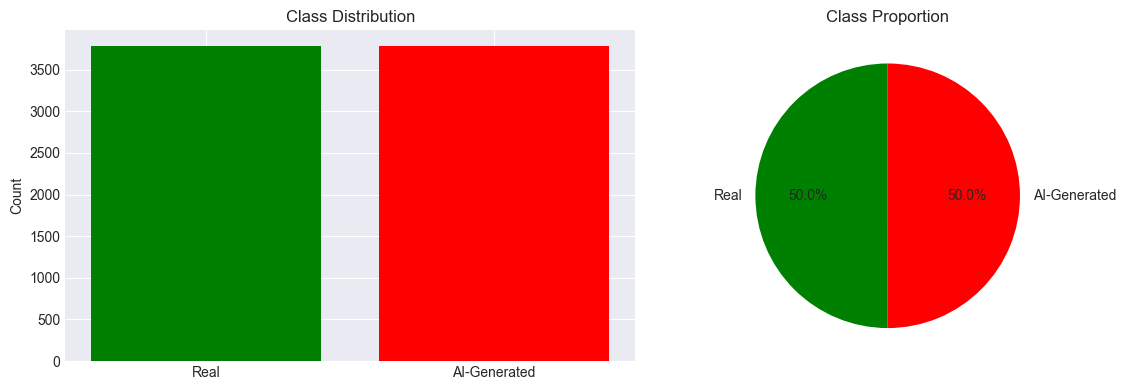

In [4]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['label'].value_counts()
axes[0].bar(['Real', 'AI-Generated'], [counts[0], counts[1]], color=['green', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
axes[1].pie([counts[0], counts[1]], labels=['Real', 'AI-Generated'],
            colors=['green', 'red'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.show()

## Step 4: Dataset Class & Augmentation

**What's new:** Stronger augmentation. `RandomResizedCrop` crops a random region
and resizes it (forces the model to handle different framings). `ColorJitter`
randomly varies brightness/contrast/saturation (prevents the model from latching
onto specific lighting). These help the model generalize and reduce overfitting.

In [5]:
class ImageDataset(Dataset):
    """Custom dataset class for loading images."""
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['label']
        if self.transform:
            image = self.transform(image)
        return image, label

# ImageNet stats (matched to what ResNet-50 was pretrained on)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms: stronger augmentation
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Eval transforms: deterministic, no augmentation
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Dataset class and transforms ready.')

Dataset class and transforms ready.


## Step 5: Train / Validation / Test Split

**What's new:** Three-way split instead of two-way. The original code used the
test set both for picking the best epoch *and* for reporting final accuracy
&mdash; that's a mild form of data leakage. Now we have:

- **Train (70%)** &mdash; what the model learns from
- **Validation (15%)** &mdash; what we use to pick the best epoch
- **Test (15%)** &mdash; touched only at the very end for the honest final number

In [6]:
# Stratified 70/15/15 split
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'\nTrain class distribution:\n{train_df["label"].value_counts().to_dict()}')
print(f'Val class distribution:   {val_df["label"].value_counts().to_dict()}')
print(f'Test class distribution:  {test_df["label"].value_counts().to_dict()}')

# Build datasets and loaders
train_dataset = ImageDataset(train_df, transform=transform_train)
val_dataset   = ImageDataset(val_df,   transform=transform_eval)
test_dataset  = ImageDataset(test_df,  transform=transform_eval)

BATCH_SIZE = 32
NUM_WORKERS = 0   # bump to 2-4 on Linux; keep at 0 on Mac/Windows to avoid issues

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

print(f'\nDataloaders ready (batch_size={BATCH_SIZE})')

Train: 5292 | Val: 1134 | Test: 1135

Train class distribution:
{1: 2646, 0: 2646}
Val class distribution:   {0: 567, 1: 567}
Test class distribution:  {1: 568, 0: 567}

Dataloaders ready (batch_size=32)


## Step 6: Pretrained ResNet-50 (the big change)

**What's new:** Instead of a custom 3-layer CNN trained from scratch, we load
ResNet-50 pretrained on ImageNet and replace only the final classification layer.

ResNet-50 has 50 layers (vs the original SimpleCNN's 3 conv layers) and was
trained on 1.2 million natural images, so its filters already detect edges,
textures, materials, shapes, and complex patterns. We're essentially recycling
all that learned visual knowledge and only training the final 'real vs AI'
decision head.

**Lighter alternative:** If ResNet-50 is too slow on your machine, swap to
`models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)`. It's about 4x
smaller and faster, with only a small accuracy cost.

In [7]:
# Load ResNet-50 with ImageNet-pretrained weights
weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)

# Replace the final fully-connected layer.
# Original: 2048 -> 1000 (ImageNet classes)
# Ours:     2048 -> 2    (Real vs AI)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2),
)

model = model.to(device)

# Quick parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: ResNet-50 (pretrained on ImageNet)')
print(f'Total parameters:     {total_params:>12,}')
print(f'Trainable parameters: {trainable_params:>12,}')
print(f'Device: {device}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/tavish/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:03<00:00, 33.2MB/s]


Model: ResNet-50 (pretrained on ImageNet)
Total parameters:       23,512,130
Trainable parameters:   23,512,130
Device: mps


## Step 7: Training Setup

**What's new:**

- **Lower learning rate (1e-4 vs 1e-3).** Pretrained weights are valuable
  &mdash; a high learning rate would smash them. We make small, careful updates.
- **AdamW with weight decay.** Slightly better generalization than plain Adam.
- **CosineAnnealingLR.** Smoothly decreases LR over training, instead of
  abrupt halvings.
- **Class weights** are still computed in case you switch to the imbalanced setup.

### Optional: train on ALL data with class weights
If you want to use *all* 17,857 fake images instead of subsampling to 3,781:
go back to Step 2 and remove the `min(n, len(all_files))` cap from `sample_class`,
or just set `SAMPLES_PER_CLASS = 999999`. The class weights computed below will
automatically rebalance the loss.

In [8]:
# Compute class weights from the TRAIN split
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f'Class weights -> Real: {class_weights[0]:.3f} | Fake: {class_weights[1]:.3f}')

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights)

LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 4

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f'\nLoss:      CrossEntropyLoss (class-weighted)')
print(f'Optimizer: AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})')
print(f'Epochs:    {NUM_EPOCHS}')

Class weights -> Real: 1.000 | Fake: 1.000

Loss:      CrossEntropyLoss (class-weighted)
Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
Scheduler: CosineAnnealingLR (T_max=4)
Epochs:    4


## Step 8: Train Model (with best-model checkpointing)

**What's new:** We track validation accuracy after every epoch and save a copy
of the model weights whenever val accuracy improves. At the end, we load those
best weights back &mdash; so even if training goes downhill in the last few
epochs, we keep the best version.

In [9]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    """Run one epoch (train or eval mode based on `train`)."""
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0
    desc = 'Train' if train else 'Eval'

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total

print('Training/eval function defined.')

Training/eval function defined.


In [10]:
# Training loop with best-model tracking
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_acc = 0.0
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

print('=' * 60)
print('TRAINING')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, optimizer, device, train=False)

    train_losses.append(train_loss); train_accs.append(train_acc)
    val_losses.append(val_loss);     val_accs.append(val_acc)

    scheduler.step()

    flag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        flag = '  <-- best so far'

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'lr={current_lr:.2e} | '
          f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
          f'val loss {val_loss:.4f} acc {val_acc:.4f}{flag}')

print('=' * 60)
print(f'Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}')
print('Loading best model weights...')
model.load_state_dict(best_model_state)

# Save best model to disk (optional, but useful for re-loading later)
torch.save(best_model_state, 'best_model.pth')
print('Saved -> best_model.pth')

TRAINING


Epoch  1/4 | lr=8.54e-05 | train loss 0.3142 acc 0.8719 | val loss 0.1912 acc 0.9268  <-- best so far


Epoch  2/4 | lr=5.00e-05 | train loss 0.1538 acc 0.9395 | val loss 0.1768 acc 0.9277  <-- best so far


Epoch  3/4 | lr=1.46e-05 | train loss 0.1063 acc 0.9575 | val loss 0.1742 acc 0.9303  <-- best so far


Epoch  4/4 | lr=0.00e+00 | train loss 0.0595 acc 0.9798 | val loss 0.1839 acc 0.9295
Best validation accuracy: 0.9303 at epoch 3
Loading best model weights...
Saved -> best_model.pth


## Step 9: Plot Training History

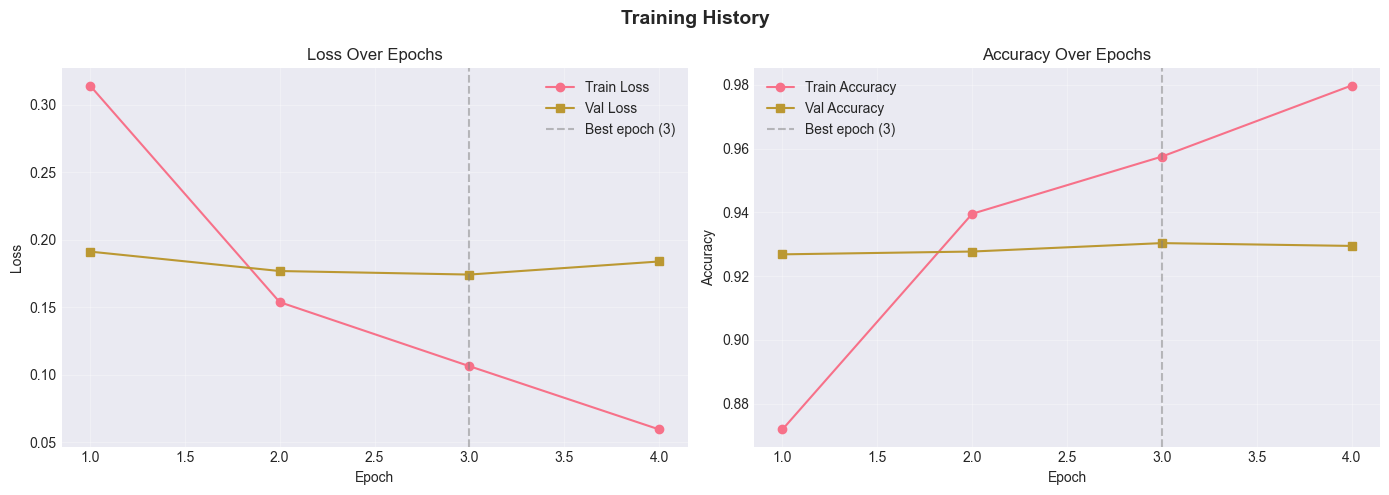

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='Train Loss', marker='o')
axes[0].plot(epochs_range, val_losses,   label='Val Loss',   marker='s')
axes[0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5,
                label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Over Epochs'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accs, label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, val_accs,   label='Val Accuracy',   marker='s')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5,
                label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Over Epochs'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Final Evaluation on the (untouched) Test Set

We never used the test set during training or model selection, so this is the
honest, generalizable accuracy.

In [12]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Test'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # prob of being AI

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print('\n' + '=' * 60)
print('FINAL TEST RESULTS')
print('=' * 60)
print(f'Accuracy:  {accuracy_score(all_labels, all_preds):.4f}')
print(f'Precision: {precision_score(all_labels, all_preds):.4f}')
print(f'Recall:    {recall_score(all_labels, all_preds):.4f}')
print(f'F1-Score:  {f1_score(all_labels, all_preds):.4f}')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['Real', 'AI-Generated']))

Test: 100%|█████████████████████████████████████████████████████████████████████████████| 36/36 [00:20<00:00,  1.75it/s]


FINAL TEST RESULTS
Accuracy:  0.9330
Precision: 0.9271
Recall:    0.9401
F1-Score:  0.9336

Classification Report:
              precision    recall  f1-score   support

        Real       0.94      0.93      0.93       567
AI-Generated       0.93      0.94      0.93       568

    accuracy                           0.93      1135
   macro avg       0.93      0.93      0.93      1135
weighted avg       0.93      0.93      0.93      1135



## Step 11: Confusion Matrix

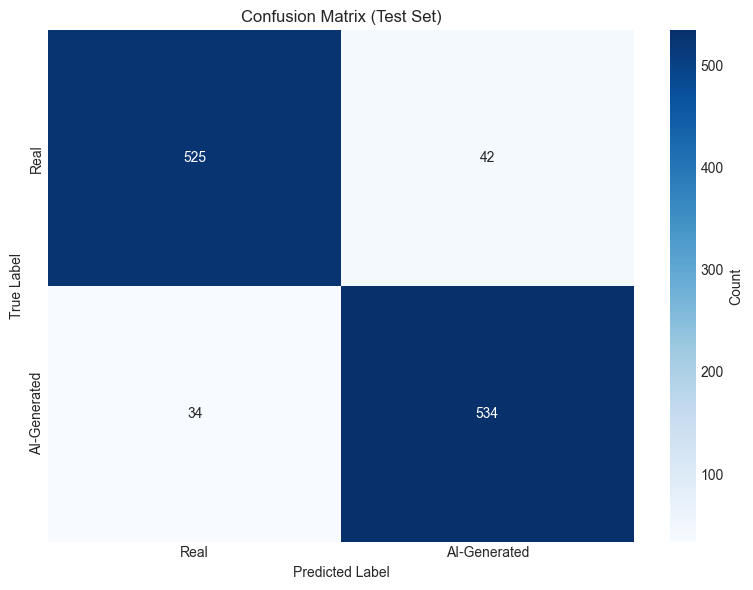

Real correctly classified: 525 / 567 (92.59%)
AI   correctly classified: 534 / 568 (94.01%)


In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'AI-Generated'],
            yticklabels=['Real', 'AI-Generated'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
real_acc = cm[0, 0] / cm[0].sum()
fake_acc = cm[1, 1] / cm[1].sum()
print(f'Real correctly classified: {cm[0,0]} / {cm[0].sum()} ({real_acc:.2%})')
print(f'AI   correctly classified: {cm[1,1]} / {cm[1].sum()} ({fake_acc:.2%})')

## Step 12: Test on Individual Images

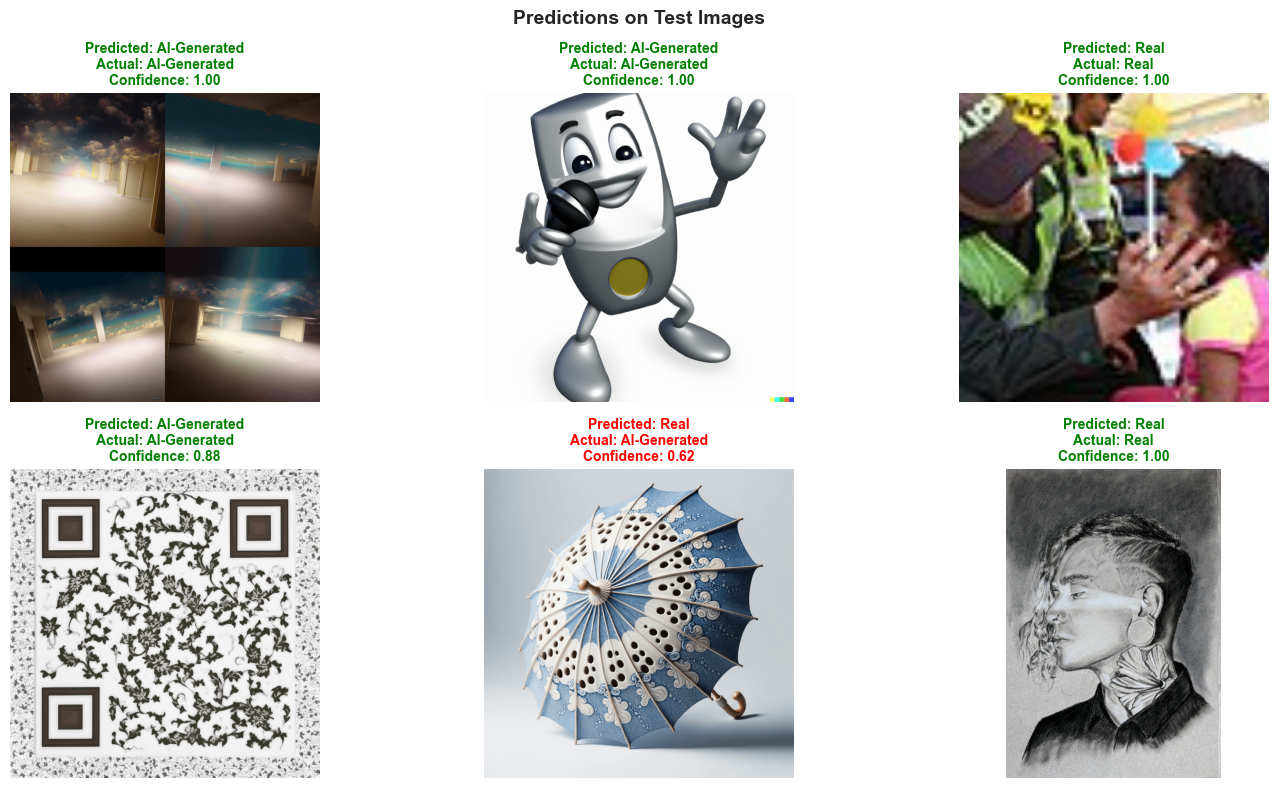

In [14]:
def predict_image(model, image_path, device, transform):
    """Predict if an image is real or AI-generated."""
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1)
        confidence = probabilities[0, predicted_class].item()

    class_name = 'Real' if predicted_class.item() == 0 else 'AI-Generated'
    return class_name, confidence

# Visualize predictions on a few random test images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Predictions on Test Images', fontsize=14, fontweight='bold')

test_samples = test_df.sample(6, random_state=SEED)
for ax, (_, row) in zip(axes.flat, test_samples.iterrows()):
    pred_class, confidence = predict_image(model, row['image_path'], device, transform_eval)
    actual_class = 'Real' if row['label'] == 0 else 'AI-Generated'

    image = Image.open(row['image_path']).convert('RGB')
    ax.imshow(image)

    color = 'green' if pred_class == actual_class else 'red'
    title = f'Predicted: {pred_class}\nActual: {actual_class}\nConfidence: {confidence:.2f}'
    ax.set_title(title, fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 13: Summary

In [ ]:
summary = f'''
╔════════════════════════════════════════════════════════════════╗
║         AI vs REAL - PROJECT SUMMARY (Transfer Learning)       ║
╚════════════════════════════════════════════════════════════════╝

✅ APPROACH:
   1. Loaded balanced sample from DALL-E dataset
   2. 70/15/15 train/val/test stratified split
   3. Pretrained ResNet-50, replaced final layer for 2-class output
   4. Fine-tuned with AdamW, lr=1e-4, cosine schedule
   5. Saved best model based on validation accuracy
   6. Reported final metrics on untouched test set

📊 MODEL:
   - Architecture:   ResNet-50 (pretrained on ImageNet)
   - Input:          224x224 RGB
   - Output:         2 classes (Real / AI-Generated)
   - Best epoch:     {best_epoch} / {NUM_EPOCHS}
   - Best val acc:   {best_val_acc:.4f}

📈 TEST SET RESULTS:
   - Accuracy:  {accuracy_score(all_labels, all_preds):.4f}
   - Precision: {precision_score(all_labels, all_preds):.4f}
   - Recall:    {recall_score(all_labels, all_preds):.4f}
   - F1-Score:  {f1_score(all_labels, all_preds):.4f}

💡 KEY CHANGES FROM ORIGINAL:
   • Pretrained ResNet-50 instead of from-scratch SimpleCNN
   • Stronger augmentation (RandomResizedCrop, ColorJitter)
   • Lower LR (1e-4) + AdamW + cosine schedule
   • Proper 3-way split (train / val / test)
   • Best-model checkpointing instead of using final-epoch model

🚀 IF YOU WANT EVEN MORE:
   1. Train at higher resolution (320 or 384)
   2. Use ALL fake images with class weights (not just 3,781)
   3. Try EfficientNet-B0 or ConvNeXt-Tiny
   4. Add Grad-CAM to visualize what the model is looking at
   5. Two-stage fine-tuning: freeze backbone first, then unfreeze
'''

print(summary)